In [68]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
conn = sqlite3.connect("base_tratada.db")

query = """
SELECT *
FROM base_tratada;
"""

df = pd.read_sql(query, conn)

# Visualizar os dados
df.head()

#testando se o banco conectou

,preco,hospedes,quartos,camas,tipo_de_quarto,nota_avaliacao,noites_minimas,quantidade_avaliacoes,tipo_de_propriedade,latitude,...,banheiros,tipo_quarto_casa_apto_inteiro,tipo_quarto_quarto_compartilhado,tipo_quarto_quarto_hotel,tipo_quarto_quarto_privativo,tipo_de_propriedade_grupo,bairro_encode,ano_mes,ipca_mensal,ipca_acumulado_ano
0,580.0,4,2.0,3.0,casa_apto_inteiro,4.93,2,86,entire condo,-22.982818,...,1.5,1,0,0,0,1,76,2025-09-01 00:00:00,0.0048,0.0426
1,1900.0,2,1.0,1.0,casa_apto_inteiro,NaN,5,0,entire rental unit,-22.984090,...,2.0,1,0,0,0,1,34,2025-09-01 00:00:00,0.0048,0.0426
2,700.0,4,1.0,1.0,casa_apto_inteiro,NaN,1,0,entire rental unit,-22.814911,...,1.0,1,0,0,0,1,96,2025-09-01 00:00:00,0.0048,0.0426
3,NaN,2,NaN,NaN,quarto_privativo,5.00,2,3,private room in rental unit,-22.981910,...,1.0,0,0,0,1,4,76,2025-09-01 00:00:00,0.0048,0.0426
4,500.0,4,1.0,1.0,casa_apto_inteiro,4.91,2,11,entire rental unit,-23.010000,...,1.0,1,0,0,0,1,8,2025-09-01 00:00:00,0.0048,0.0426


In [70]:
df_tratado = df[df["preco"] <= 7000].copy()

#Limita o preco das diaria ate 7k

In [71]:
df_tratado_price_min = df_tratado[
    (df_tratado["preco"] >= 65) &
    (df_tratado["quartos"] <= 15) &
    (df_tratado["banheiros"] <= 12)
].copy()

#atribui ao novo dataframe valores de limete pós remocao de outliers

In [72]:
df_tratado_price_min[
    [
        "preco",
        "hospedes",
        "quartos",
        "camas",
        "nota_avaliacao",
        "noites_minimas",
        "quantidade_avaliacoes",
        "latitude",
        "longitude",
        "banheiros",
        "tipo_de_quarto"
    ]
].describe()
df_tratado_price_min.info()

<class 'pandas.DataFrame'>
Index: 37711 entries, 0 to 43067
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   preco                             37711 non-null  float64
 1   hospedes                          37711 non-null  int64  
 2   quartos                           37711 non-null  float64
 3   camas                             37700 non-null  float64
 4   tipo_de_quarto                    37711 non-null  str    
 5   nota_avaliacao                    30097 non-null  float64
 6   noites_minimas                    37711 non-null  int64  
 7   quantidade_avaliacoes             37711 non-null  int64  
 8   tipo_de_propriedade               37711 non-null  str    
 9   latitude                          37711 non-null  float64
 10  longitude                         37711 non-null  float64
 11  bairro                            37711 non-null  str    
 12  ano                 

In [73]:
variaveis = [
  "preco",
    "quartos",
    "banheiros",
    "latitude",
    "longitude",
    "camas",
    "nota_avaliacao",
    "quantidade_avaliacoes",
    "hospedes",
    "noites_minimas",
    "tipo_quarto_casa_apto_inteiro",
    "tipo_quarto_quarto_compartilhado",
    "tipo_quarto_quarto_hotel",
    "tipo_quarto_quarto_privativo",
    "tipo_de_propriedade_grupo",
    "ipca_mensal",
    "ipca_acumulado_ano"
]

df_corr = df_tratado_price_min[variaveis]

In [74]:
corr_matrix = df_corr.corr()

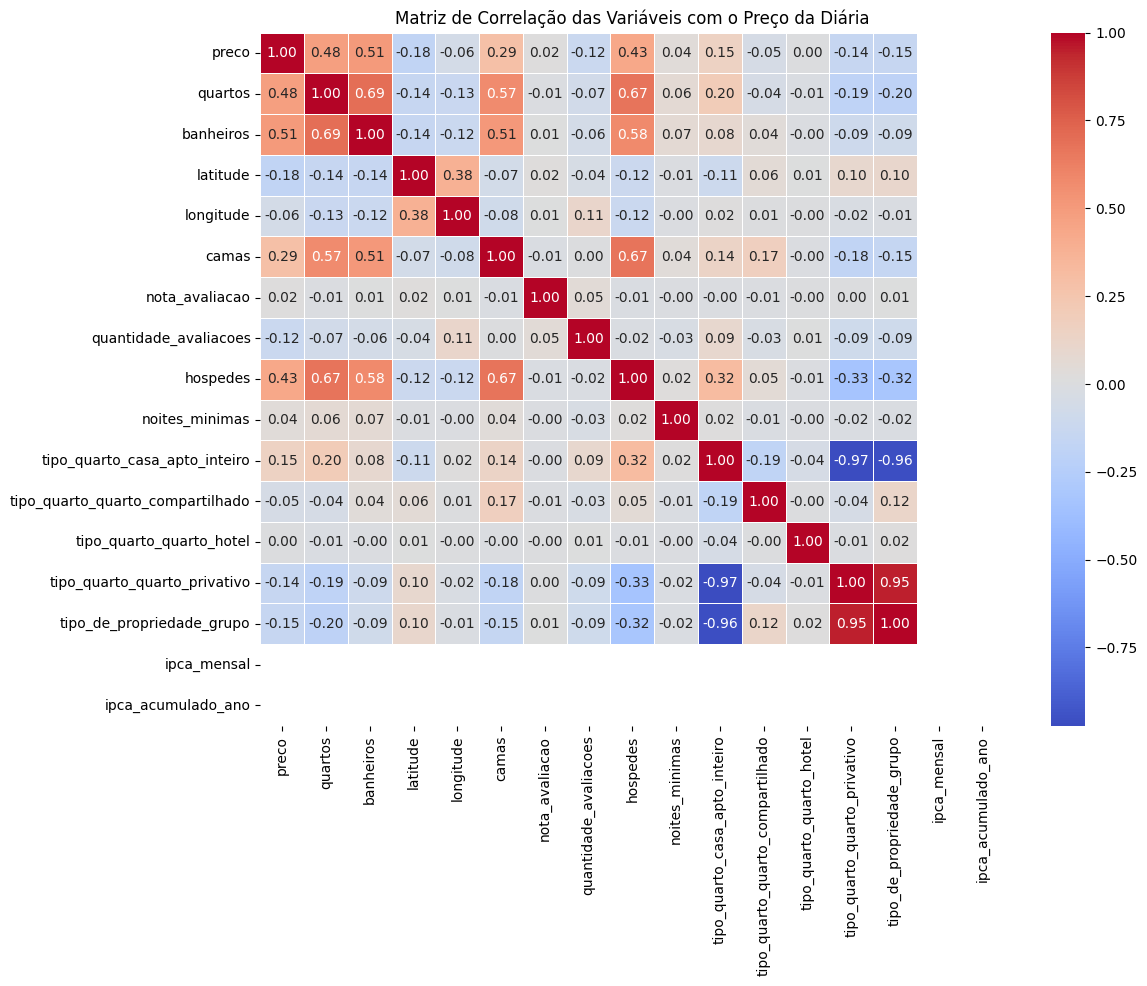

In [75]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis com o Preço da Diária")
plt.show()

Treinando algoritmo


### Modelo sem transformação log (baseline)

In [76]:
# Base final definida a partir da análise exploratória

df_modelo = df_tratado_price_min.copy()


In [77]:
# Ajuste do preço pela inflação (IPCA)

df_modelo["preco_ajustado"] = (
    df_modelo["preco"] * (1 + df_modelo["ipca_acumulado_ano"])
)

In [78]:
# Definição do target

y = df_modelo["preco_ajustado"]

In [79]:
# Definição das variáveis explicativas conforme decisão do grupo

X = df_modelo.drop(
    columns=[
        "preco",
        "preco_ajustado",
        "ano_mes",
        "bairro_encode",
        "bairro",
        "tipo_de_propriedade",
        "tipo_de_quarto",
        "ano",
        "mes",
        "ipca_acumulado_ano",
        "ipca_mensal"
    ]
)

In [80]:
# Quantidade de valores nulos por coluna

df_modelo.isna().sum()

preco                                  0
hospedes                               0
quartos                                0
camas                                 11
tipo_de_quarto                         0
nota_avaliacao                      7614
noites_minimas                         0
quantidade_avaliacoes                  0
tipo_de_propriedade                    0
latitude                               0
longitude                              0
bairro                                 0
ano                                    0
mes                                    0
banheiros                              0
tipo_quarto_casa_apto_inteiro          0
tipo_quarto_quarto_compartilhado       0
tipo_quarto_quarto_hotel               0
tipo_quarto_quarto_privativo           0
tipo_de_propriedade_grupo              0
bairro_encode                          0
ano_mes                                0
ipca_mensal                            0
ipca_acumulado_ano                     0
preco_ajustado  

In [81]:
# # Remoção de valores ausentes

# df_modelo = df_modelo.dropna()

In [82]:
# Target

y = df_modelo["preco_ajustado"]

In [83]:
# Features numéricas finais (decisão do grupo)

X = df_modelo.drop(
    columns=[
        "preco",
        "preco_ajustado",
        "ano_mes",
        "bairro_encode",
        "bairro",
        "tipo_de_propriedade",
        "tipo_de_quarto",
        "ano",
        "mes",
        "ipca_acumulado_ano",
        "ipca_mensal"
    ]
)

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [85]:
from sklearn.ensemble import RandomForestRegressor

modelo_baseline = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

modelo_baseline.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [86]:
y_pred = modelo_baseline.predict(X_test)

In [87]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Baseline sem log")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Baseline sem log
MAE: 261.8904555396349
RMSE: 523.3526651972844
R²: 0.4695273002228799


### Modelo com transformação log

In [88]:
# Transformação logarítmica do preço ajustado (target)

df_modelo["preco_log"] = np.log1p(df_modelo["preco_ajustado"])

In [89]:
# Target log

y_log = df_modelo["preco_log"]

In [90]:
# MESMO X do baseline (somente variáveis numéricas)

X_log = X.copy()

In [91]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log,
    y_log,
    test_size=0.3,
    random_state=42
)

In [92]:
modelo_log = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

modelo_log.fit(X_train_log, y_train_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [93]:
y_pred_log = modelo_log.predict(X_test_log)

In [94]:
# Converter valores de volta para reais

y_pred_log_reais = np.expm1(y_pred_log)
y_test_reais = np.expm1(y_test_log)

In [95]:
mae_log = mean_absolute_error(y_test_reais, y_pred_log_reais)
rmse_log = np.sqrt(mean_squared_error(y_test_reais, y_pred_log_reais))
r2_log = r2_score(y_test_reais, y_pred_log_reais)

print("Modelo com transformação log")
print("MAE:", mae_log)
print("RMSE:", rmse_log)
print("R²:", r2_log)

Modelo com transformação log
MAE: 231.54131137166388
RMSE: 525.8655618078999
R²: 0.4644209028844656


### Comparação entre os modelos

A tabela abaixo apresenta a comparação entre o modelo baseline (sem transformação log)
e o modelo com transformação logarítmica do preço, utilizando as métricas MAE, RMSE e R².

In [96]:
# # Cria a tabela de comparação

# from IPython.display import display
# import pandas as pd

# comparacao = pd.DataFrame({
#     "Modelo": ["Sem log", "Com log"],
#     "MAE": [mae, mae_log],
#     "RMSE": [rmse, rmse_log],
#     "R²": [r2, r2_log]
# })

In [97]:
# # Mostrar a tabela
# display(comparacao)

# # Comparação automática baseada no MAE
# melhor_com_log = mae_log < mae

# if melhor_com_log:
#     print("✅ O modelo com transformação log apresentou melhor desempenho em MAE.")
# else:
#     print("ℹ️ O modelo sem log apresentou desempenho semelhante ou melhor em MAE.")